In [1]:
!git clone https://github.com/Niharika5389/LGCCA-FER.git
%cd LGCCA-FER

Cloning into 'LGCCA-FER'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 72 (delta 26), reused 51 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 746.87 KiB | 13.34 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/kaggle/working/LGCCA-FER


In [2]:
!ls

assets	configs  data  models  notebooks  README.md  requirements.txt  utils


In [3]:
import os

print(os.listdir("/kaggle/input"))
dataset_path = "/kaggle/input/datasets/msambare/fer2013"

print(os.listdir(dataset_path))

['datasets']
['test', 'train']


In [4]:
!git pull origin main

From https://github.com/Niharika5389/LGCCA-FER
 * branch            main       -> FETCH_HEAD
Already up to date.


In [5]:
from configs.config import *
from data.dataset import *
from data.transforms import *

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from configs.config import (
    DEVICE,
    LEARNING_RATE,
    NUM_EPOCHS,
    CHECKPOINT_PATH
)

from data.dataset import get_dataloaders
from models.backbone import EfficientNetBackbone
from utils.train import train_model

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
train_loader, val_loader, test_loader = get_dataloaders()

print("Training batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Testing batches :", len(test_loader))

Training batches : 718
Validation batches : 180
Testing batches : 225


In [8]:
model = EfficientNetBackbone()

model = model.to(DEVICE)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s] 


EfficientNetBackbone(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (

In [9]:
criterion = nn.CrossEntropyLoss()

In [10]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [11]:
import os

os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

In [12]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH
)


Epoch 1/20
Train Loss: 1.2138 | Train Accuracy: 54.10%
Validation Loss: 1.0504 | Validation Accuracy: 60.14%
Best model saved.

Epoch 2/20
Train Loss: 1.0243 | Train Accuracy: 61.77%
Validation Loss: 0.9617 | Validation Accuracy: 64.61%
Best model saved.

Epoch 3/20
Train Loss: 0.9471 | Train Accuracy: 64.30%
Validation Loss: 0.9652 | Validation Accuracy: 63.44%

Epoch 4/20
Train Loss: 0.8905 | Train Accuracy: 66.98%
Validation Loss: 0.9641 | Validation Accuracy: 64.14%

Epoch 5/20
Train Loss: 0.8417 | Train Accuracy: 68.51%
Validation Loss: 0.9231 | Validation Accuracy: 66.28%
Best model saved.

Epoch 6/20
Train Loss: 0.7870 | Train Accuracy: 70.60%
Validation Loss: 0.9254 | Validation Accuracy: 66.04%

Epoch 7/20
Train Loss: 0.7441 | Train Accuracy: 72.26%
Validation Loss: 0.9240 | Validation Accuracy: 66.14%

Epoch 8/20
Train Loss: 0.6942 | Train Accuracy: 74.35%
Validation Loss: 0.9627 | Validation Accuracy: 66.27%

Epoch 9/20
Train Loss: 0.6514 | Train Accuracy: 75.65%
Validation

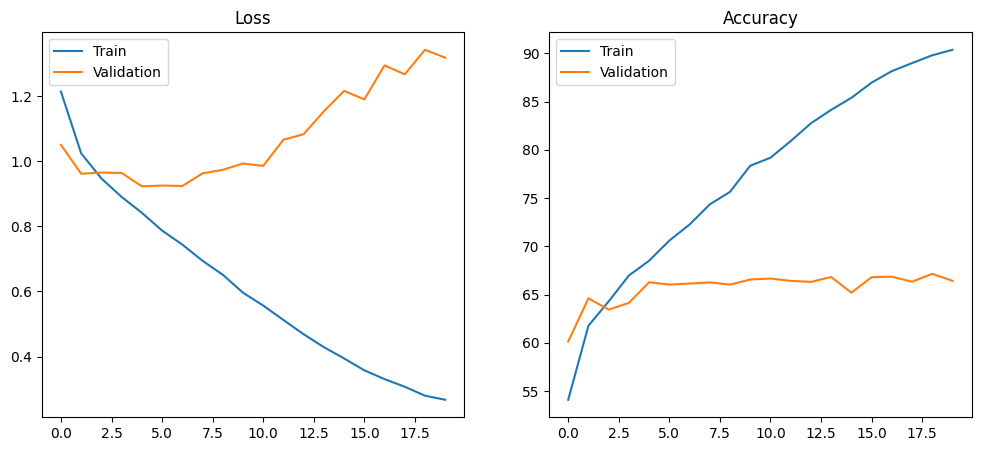

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs,label="Train")
plt.plot(val_accs,label="Validation")
plt.legend()
plt.title("Accuracy")

plt.show()

In [17]:
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

EfficientNetBackbone(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (